# BABP 4주차: 환경에 대한 적응의 결과, 진화

## 0. 환경 설정

**라이브러리 다운로드**

지난 시간에 배운 Biopython과, matplotlib을 기반으로 확장된 통계 시각화를 제공하는 라이브러리인 seaborn을 다운로드 해봅시다.

In [1]:
!pip install biopython seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


오늘 실습에 필요한 라이브러리들을 전부 `import`해 봅시다.<br>
저같은 경우는 아래의 셀처럼 필요한 라이브러리들을 한 번에 불러오고 기능에 따라 나누는 편입니다.

실제 프로그래밍을 할 때는 `requirements.txt` 파일을 생성해 라이브러리들의 이름과 버전을 기록하여 다른 곳에서도 동일한 결과를 출력하도록 관리하곤 합니다.

당장 저희는 하나의 `ipynb` 파일에서 실행하고 있으니 아래처럼만 해도 괜찮습니다.

In [2]:
### Import libraries
# for matrix processing
import numpy as np
import pandas as pd

# for figure plotting
import matplotlib.pyplot as plt
import seaborn as sns

# for extract & read fasta files
from Bio import Entrez
from Bio import SeqIO
from Bio import AlignIO

## 1. Opsin Paralog 비교 분석하기

### 1-1. BLAST로 서열 비교하기

먼저 지난 시간에 한 번 사용해본 BLAST로 옵신 서열들을 비교해봅시다.

앞서 NCBI에서 내려받은 `opn1*_gene_fna` 파일들을 사용하며, BLAST는 NCBI 웹사이트에서 진행합니다.

아래의 절차를 수행해봅시다. 자세한 내용은 pdf를 참조해주세요.

① 한 쌍의 유전자 서열을 비교할 것이므로 'blastn' 탭에서 진행합니다. 만약 단백질 서열이라면 'blastp'에서 진행하면 됩니다.

② 'Align two or more sequences' 설정을 체크합니다. 데이터베이스 대신 저희가 직접 입력한 파일을 기준으로 사용합니다.

③ Subject Sequence에는 적색 옵신 유전자(opn1lw)를 입력하고, Query Sequence에는 녹색 옵신 유전자(opn1mw)를 입력합시다.

④ 알고리즘은 'blastn'을 사용합니다. 다른 결과가 보고싶으시다면 'megablast'로 하셔도 좋습니다.

⑤ 결과를 확인하고 동일한 설정으로 청색 옵신 유전자(opn1sw)와의 결과와 비교해봅니다.

수행 결과가 어떻나요? 적색과 녹색 옵신은 Query cover가 약 95%로 매우 유사한 반면, 적색과 청색 옵신은 13%에 불과했습니다.

이를 통해, 저희는 다음의 가설을 세워볼 수 있습니다.

**'적색과 청색 옵신보다 적색과 녹색 옵신이 상대적으로 더 늦게 분기되었을 것이다'**

예리하신 분들게 하나의 질문을 드리겠습니다.

Q. 우리는 query와 subject에 각 하나씩 서열 파일을 입력했는데, 어째서 B:AST 결과는 두 개가 나왔을까요? 

여러분들이 한 번 직접 고민해보시길 바랍니다. 정답이 궁금하신 분들은 제게 질문하셔도 좋습니다.

### 1-2. MSA로 서열 비교하기

그러나, 저희가 사용하는 **데이터**와 **분석 방법**에 대하여 조금 더 고민해볼 필요가 있습니다.

저희의 분석 목적은 세 옵신 paralog의 서열을 서로 비교하고, 오랜 시간이 지났음에도 그 기능의 수행에 있어 서열이 여전히 보존되는 부위가 있는지 확인하는 것이었습니다.<br>
다만 지금 사용하는 데이터는 유전자 데이터로, intron을 비롯해 단백질로 번역되지 않아 기능의 수행과는 무관한 서열들이 포함되어 있습니다.<br>
또한 BLAST는 분명 강력한 검색 도구이지만 사실 여러 개의 서열을 한 번에 정렬하는 데에 가장 좋은 도구는 아닙니다.

이를 위해 이번에는 옵신의 **단백질** 서열을 **MSA 알고리즘**을 통해 분석해봅시다.

**Entrez를 활용한 데이터 추출 자동화**

앞서 import한 Entrez를 사용하여 현재 작업 환경에서 NCBI 데이터베이스에 직접 접근해봅시다.<br>
`Entrez`는 Python에서 NCBI 데이터베이스에 접근하기 위한 Biopython 모듈 중 하나입니다.

- `Entrez.esearch()` : 검색어를 이용해 NCBI 데이터베이스를 검색하고, 일치하는 레코드의 ID를 가져옵니다.
- `Entrez.efetch()` : ID 또는 accession을 이용해 실제 서열이나 문헌 레코드를 원하는 형식으로 가져옵니다.
- `Entrez.read()` : Entrez에서 반환된 XML 형식의 결과를 Python의 dictionary나 list 형태로 변환합니다.

In [ ]:
### .esearch() - 타겟 서열의 accession code 추출 함수
# Python의 dictionary 자료형을 활용합니다.
# dictionary 자료형은 한 쌍의 key와 value로 이루어져 있으며, 리스트의 인덱스처럼 딕셔너리의 키를 활용할 수 있습니다.
# 예를 들어, list[n]으로 리스트의 n+1번째 값에 접근하듯 dict['key']로 그 'key'에 해당하는 값을 호출할 수 있습니다.

# NCBI 데이터베이스 접근을 위한 이메일 설정 
Entrez.email = "your.email@example.com"  # 본인의 이메일로 변경해도 무방함

# 분석할 인간 opsin의 유전자 이름을 딕셔너리에 저장
opsin_genes = {                 # {}로 딕셔너리를 선언할 수 있음
    "Red_Opsin": "OPN1LW",      # OPN1LW(Red), OPN1MW(Green), OPN1SW(Blue)
    "Green_Opsin": "OPN1MW",
    "Blue_Opsin": "OPN1SW"
}

opsin_accessions = {}

for name, gene in opsin_genes.items():   # kwey, value를 하나씩 가져와 반복

    # NCBI Protein에서 유전자 이름과 생물 종으로 검색
    handle = Entrez.esearch(db="protein",   # Protein 데이터베이스 지정
        term=f'{gene}[Gene Name] AND "Homo sapiens"[Organism] AND RefSeq[Filter]',
        retmax=1,
        idtype="acc")

    result = Entrez.read(handle)
    handle.close()

    # 검색 결과의 첫 번째 accession을 저장하여 RefSeq ID 딕셔너리로 세팅
    opsin_accessions[name] = result["IdList"][0]

print(opsin_accessions)

{'Red_Opsin': 'NP_064445.2', 'Green_Opsin': 'NP_000504.1', 'Blue_Opsin': 'NP_001372054.1'}


In [ ]:
### .efetch() - accession code로 실제 서열을 가져오는 함수

print("NCBI에서 단백질 서열을 다운로드 중")
records = []   # 가져온 서열을 저장할 임시 리스트
for name, acc in opsin_accessions.items():
    handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode="text")   # FASTA 파일 형식 지정
    record = SeqIO.read(handle, "fasta")
    record.id = name    # 정렬 결과창에서 보기 쉽게 ID를 직관적으로 변경
    record.description = ""
    records.append(record)
    handle.close()

# 가져온 서열을 로컬 파일로 저장
para_unaligned_file = "opsins_paralog_unaligned.fasta"
SeqIO.write(records, para_unaligned_file, "fasta")
print(f"서열 다운로드 완료: {para_unaligned_file}")

NCBI에서 단백질 서열을 다운로드 중
서열 다운로드 완료: opsins_paralog_unaligned.fasta


번거로운 검색 작업 없이, 간단히 NCBI 데이터베이스로부터 원하는 서열 파일을 가져올 수 있었습니다.

파일을 한 번 확인해보세요. 메모장으로 열면, 여러 서열이 담겨 있는 FASTA 형식을 확인하실 수 있습니다.

**MSA 수행**

이제 가져온 서열 파일을 바탕으로 MSA를 수행해봅시다.

저희가 처음부터 직접 MSA 알고리즘을 Python으로 구현해볼 수도 있겠지만, 이미 여러 훌륭하신 분들이 만들어놓은 검증된 플랫폼이 있기 때문에 연구 목적에 따라 필요한 웹 도구를 활용하는 능력이 실무에서는 훨씬 중요합니다.

다운로드한 `opsins_paralog_unaligned.fasta` 파일을 아래 링크로 접속하여 업로드해봅시다.

**https://www.ebi.ac.uk/jdispatcher/msa/clustalo**

`OUTPUT FORMAT` 설정을 `ClustalW`로 설정해주세요. `Title`은 아무렇게나 해도 좋습니다.
나중에 실습을 마쳤을 때, 다른 알고리즘으로 설정해서 다시 시도해 보시는 것도 추천합니다. 이번 주차의 README에서도 설명드렸듯이, MSA는 알고리즘에 따라 그 결과가 달라질 수 있으니까요.

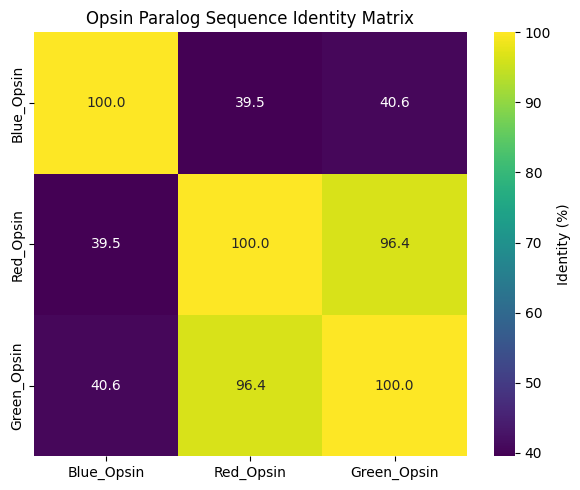

In [7]:
# Clustal Omega에서 다운로드한 FASTA 파일 읽기
alignment = AlignIO.read("opsins_paralog_aligned.fa", "fasta")

# 서열 수 및 길이 확인
num_seqs = len(alignment)
seq_len = alignment.get_alignment_length()
seq_names = [record.id for record in alignment]

# 유사도(Identity %) 행렬 초기화
identity_matrix = np.zeros((num_seqs, num_seqs))

# 모든 서열 쌍 간의 일치율 계산
for i in range(num_seqs):
    for j in range(num_seqs):
        matches = sum(1 for k in range(seq_len) if alignment[i, k] == alignment[j, k] and alignment[i, k] != '-')
        # 갭(-)을 제외한 정렬 길이 기준으로 계산
        total_len = sum(1 for k in range(seq_len) if (alignment[i, k] != '-' or alignment[j, k] != '-'))
        identity_matrix[i, j] = (matches / total_len) * 100 if total_len > 0 else 0

# 판다스 데이터프레임으로 변환
df = pd.DataFrame(identity_matrix, index=seq_names, columns=seq_names)

# Seaborn 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'Identity (%)'})
plt.title("Opsin Paralog Sequence Identity Matrix")
plt.tight_layout()
plt.show()

Sequence Identity 계산 및 시각화 결과, 적색 옵신과 녹색 옵신의 유사도는 높은 반면, 청색 옵신은 다른 두 옵신과의 유사도가 높지 않은 것으로 보입니다.<br>
그럼에도 약 40%의 유사도를 유지하는 것으로 보아 청색 옵신과도 공유하고 있는 부분이 분명 존재하는 것으로 생각되기도 하네요.

인간의 세 옵신 paralog가 7-TM 구조를 유지한다는 점을 떠올리면, 이 부분이 시간이 지나더라도 기능을 유지하기 위한 보존 서열일 수도 있습니다. 그러니, 아래의 가설을 세워봅시다.

**7-TM 구조를 이루는 서열은 세 옵신에서 모두 보존되어 있을 것이다.**

그렇다면 가설을 검증하기 위해 긴 시퀀스 중 어느 부위가 유사할지 그래프를 그려봅시다.

Alignment length: 367
Red opsin actual length: 364


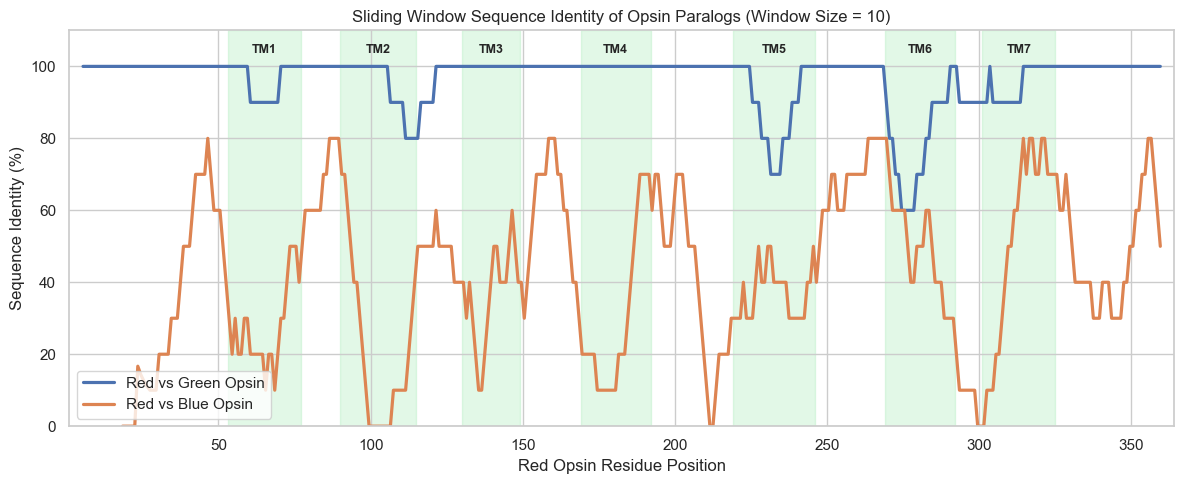

In [7]:
# 1. 정렬된 FASTA 파일 읽기
alignment_file = "data/opsins_paralog_aligned.fa"
alignment = AlignIO.read(alignment_file, "fasta")

# 2. 각 서열을 이름별로 딕셔너리에 저장
aligned_seqs = {}

for record in alignment:
    aligned_seqs[record.id] = str(record.seq)

seq_red = aligned_seqs["Red_Opsin"]
seq_green = aligned_seqs["Green_Opsin"]
seq_blue = aligned_seqs["Blue_Opsin"]

# 3. 적색 opsin의 실제 아미노산 위치와 alignment column 연결
# Red sequence에서 gap이 아닌 column만 저장
red_alignment_columns = []

for column, amino_acid in enumerate(seq_red):
    if amino_acid != "-":
        red_alignment_columns.append(column)


alignment_length = alignment.get_alignment_length()
red_length = len(red_alignment_columns)

print(f"Alignment length: {alignment_length}")
print(f"Red opsin actual length: {red_length}")


# 4. 슬라이딩 윈도우 설정
window_size = 10
results = []


# 적색 opsin의 실제 residue 번호를 기준으로 window 이동
for start in range(red_length - window_size + 1):

    # 현재 window에 포함되는 alignment column
    window_columns = red_alignment_columns[start : start + window_size]

    match_rg = 0
    match_rb = 0

    valid_rg = 0
    valid_rb = 0

    for column in window_columns:
        red_aa = seq_red[column]
        green_aa = seq_green[column]
        blue_aa = seq_blue[column]

        # Red와 Green 모두 아미노산이 존재하는 위치만 비교
        if green_aa != "-":
            valid_rg += 1
            if red_aa == green_aa:
                match_rg += 1

        # Red와 Blue 모두 아미노산이 존재하는 위치만 비교
        if blue_aa != "-":
            valid_rb += 1
            if red_aa == blue_aa:
                match_rb += 1

    # Sequence identity 계산
    score_rg = (match_rg / valid_rg * 100 if valid_rg > 0 else np.nan)
    score_rb = (match_rb / valid_rb * 100 if valid_rb > 0 else np.nan)

    # 실제 Red opsin residue 기준 window 중앙 위치
    start_position = start + 1
    end_position = start + window_size
    center_position = (start_position + end_position) / 2

    # Seaborn에서 사용하기 좋은 long-form 형태로 저장
    results.append({
        "Position": center_position,
        "Comparison": "Red vs Green Opsin",
        "Identity": score_rg
    })

    results.append({
        "Position": center_position,
        "Comparison": "Red vs Blue Opsin",
        "Identity": score_rb
    })


identity_df = pd.DataFrame(results)

# 5. UniProt에 기록된 Red opsin의 7TM 영역
# 위치는 1부터 시작하며 양 끝 residue를 모두 포함
tm_regions = [
    ("TM1", 53, 77),
    ("TM2", 90, 115),
    ("TM3", 130, 149),
    ("TM4", 169, 192),
    ("TM5", 219, 246),
    ("TM6", 269, 292),
    ("TM7", 301, 325)
]

# 6. Sequence identity 시각화
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# 7TM 영역을 배경에 표시
tm_color = sns.color_palette("pastel")[2]
for tm_name, start, end in tm_regions:

    ax.axvspan(
        start,
        end,
        color=tm_color,
        alpha=0.25,
        zorder=0
    )

    ax.text(
        (start + end) / 2,
        103,
        tm_name,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Sequence identity line plot
sns.lineplot(
    data=identity_df,
    x="Position",
    y="Identity",
    hue="Comparison",
    linewidth=2.3,
    errorbar=None,
    ax=ax
)

ax.set_title(
    f"Sliding Window Sequence Identity of Opsin Paralogs "
    f"(Window Size = {window_size})"
)
ax.set_xlabel("Red Opsin Residue Position")
ax.set_ylabel("Sequence Identity (%)")
ax.set_xlim(1, red_length)
ax.set_ylim(0, 110)
ax.legend(
    title=None,
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.show()

분석 결과는 오히려 조금 달랐습니다. TM6, 7은 보존이 잘 되어 있는 반면, 나머지는 그렇지 않거나 오히려 더 낮은 경향을 보이기도 했습니다.

이는 정확한 문헌을 살펴봐야겠지만, 적어도 저희의 가설이 잘 들어맞지 않는다는 점을 알려줍니다.

어쩌면 막 관통 부위이므로 해당 서열들이 변이가 일어났으나 같은 성질인 소수성 아미노산으로 변하여 그런 것이거나,<br>
오히려 낮아진 점을 고려하면 TM 및 그 근처의 변이가 색 파장 신호를 달리 감지하는 원인일 수도 있을 겁니다.

## 2. Opsin Ortholog 비교 분석하기

이번에는 옵신의 ortholog의 비교를 위해, 여러 종의 청색 옵신 서열을 가져와 비교해봅시다.

Accession code는 제가 이미 찾아놓았고 위의 paralog 분석과 동일하므로 간단히 아래의 코드를 읽어보시고 실행해보세요.

In [ ]:
# RefSeq ID 딕셔너리 세팅
opsin_accessions = {
    "Zebrafish_OPN1SW": "NP_571394.1",      # Danio rerio
    "Chicken_OPN1SW": "NP_990769.1",        # Gallus gallus
    "Finch_OPN1SW": "XP_005430875.1",       # Geospiza fortis
    "Mouse_OPN1SW": "NP_031564.1",          # Mus musculus
    "Chimpanzee_OPN1SW": "NP_001009127.1",  # Pan troglodytes
    "Human_OPN1SW": "NP_001372054.1"        # Homo Sapiens
}

print("NCBI에서 단백질 서열을 다운로드 중")
records = []
for name, acc in opsin_accessions.items():
    # NCBI Protein 데이터베이스에서 FASTA 형식으로 서열 가져오기
    handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    record.id = name  # 정렬 결과창에서 보기 쉽게 ID를 직관적으로 변경
    record.description = ""
    records.append(record)
    handle.close()

# 가져온 서열을 로컬 파일로 저장
ortho_unaligned_file = "opsins_ortholog_unaligned.fasta"
SeqIO.write(records, ortho_unaligned_file, "fasta")
print(f"서열 다운로드 완료: {ortho_unaligned_file}")

NCBI에서 단백질 서열을 다운로드 중
서열 다운로드 완료: opsins_ortholog_unaligned.fasta


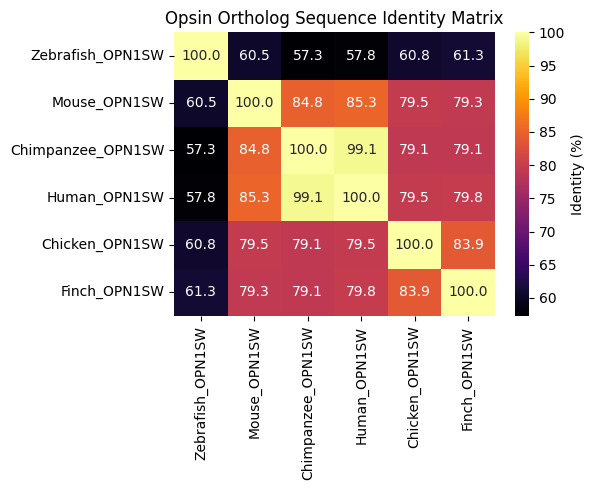

In [ ]:
# Clustal Omega에서 다운로드한 FASTA 파일 읽기
alignment = AlignIO.read("opsins_ortholog_aligned.fa", "fasta")

# 서열 수 및 길이 확인
num_seqs = len(alignment)
seq_len = alignment.get_alignment_length()
seq_names = [record.id for record in alignment]

# 유사도(Identity %) 행렬 초기화
identity_matrix = np.zeros((num_seqs, num_seqs))

# 모든 서열 쌍 간의 일치율 계산
for i in range(num_seqs):
    for j in range(num_seqs):
        matches = sum(1 for k in range(seq_len) if alignment[i, k] == alignment[j, k] and alignment[i, k] != '-')
        # 갭(-)을 제외한 정렬 길이 기준으로 계산
        total_len = sum(1 for k in range(seq_len) if (alignment[i, k] != '-' or alignment[j, k] != '-'))
        identity_matrix[i, j] = (matches / total_len) * 100 if total_len > 0 else 0

# 판다스 데이터프레임으로 변환
df = pd.DataFrame(identity_matrix, index=seq_names, columns=seq_names)

# Seaborn 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, fmt=".1f", cmap="inferno", cbar_kws={'label': 'Identity (%)'})
plt.title("Opsin Ortholog Sequence Identity Matrix")
plt.tight_layout()
plt.show()

**결과 해석 및 마무리**

히트맵의 대각선은 각 서열을 자기 자신과 비교한 결과이므로 모두 100%이며, 서열 사이의 관계를 해석할 때에는 대각선 밖의 값을 확인합니다.

- 비교한 종 중 유일한 어류인 **Zebrafish**는 다른 척추동물과 상대적으로 낮은 sequence identity를 보였지만, 모든 종과 최소 **57.3% 이상**의 서열을 공유했습니다.
- 같은 조류에 속하는 **Chicken과 Finch**는 **83.9%**의 sequence identity를 보였습니다.
- 포유류인 **Mouse, Chimpanzee, Human**은 서로 최소 **84.8% 이상**의 sequence identity를 보였습니다.
- 특히 가까운 영장류인 **Human과 Chimpanzee**의 OPN1SW는 **99.1%**로 매우 유사했습니다.

이러한 결과는 같은 기능을 수행하는 ortholog라도 종이 분화된 이후 각 계통에서 변이가 축적되며 서열이 달라질 수 있음을 보여줍니다. 동시에 분류학적으로 가까운 종일수록 더 최근의 공통 조상을 공유하므로, 단백질 서열도 더 유사하게 남아 있는 경향을 확인할 수 있습니다.

다만 sequence identity 행렬만으로 정확한 계통수나 분기 순서를 확정할 수는 없습니다. 이번 결과는 Zebrafish가 다른 종들과 상대적으로 멀고, 조류끼리·포유류끼리·특히 영장류끼리 더 가까운 관계를 보인다는 **대략적인 계통적 경향**을 보여주는 자료로 해석할 수 있습니다.

이번 실습에서는 인간의 적색·녹색·청색 opsin **paralog**를 비교하여 유전자 중복 이후의 기능적 분화를 살펴보고, 여러 척추동물의 OPN1SW **ortholog**를 비교하여 종 분화 이후에도 남아 있는 서열의 보존성을 확인했습니다.

이를 통해 여러 서열을 수집하고 정렬하는 과정은 단순히 유사한 문자를 찾는 작업이 아니라, 현재의 서열에 남아 있는 **유전자 중복과 종 분화의 흔적을 읽어내는 생물정보학적 방법**임을 알 수 있습니다.